In [3]:
import pandas as pd
import numpy as np
import torch
from torchvision import datasets
from torchvision.transforms import ToTensor

In [4]:
train_data = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=ToTensor()
)

In [5]:
train_data

Dataset MNIST
    Number of datapoints: 60000
    Root location: ./data
    Split: Train
    StandardTransform
Transform: ToTensor()

In [6]:
print(len(train_data))

60000


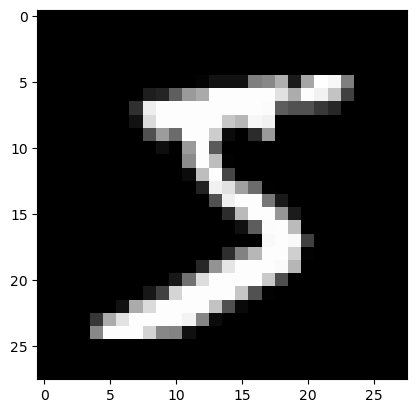

In [13]:
import matplotlib.pyplot as plt
image, label = train_data[0]
plt.imshow(image.squeeze(), cmap="gray")
plt.show()

In [14]:
test_data = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=ToTensor()
)

In [15]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_data,
    batch_size = 32,
    shuffle = True
)

test_loader = DataLoader(
    test_data,
    batch_size = 32,
    shuffle = False
)

In [16]:
print("Training samples:", len(train_data))
print("Test samples:", len(test_data))

Training samples: 60000
Test samples: 10000


In [17]:
images, labels = next(iter(train_loader))

print("Image: ", images.shape)
print("Label: ", labels.shape)

Image:  torch.Size([32, 1, 28, 28])
Label:  torch.Size([32])


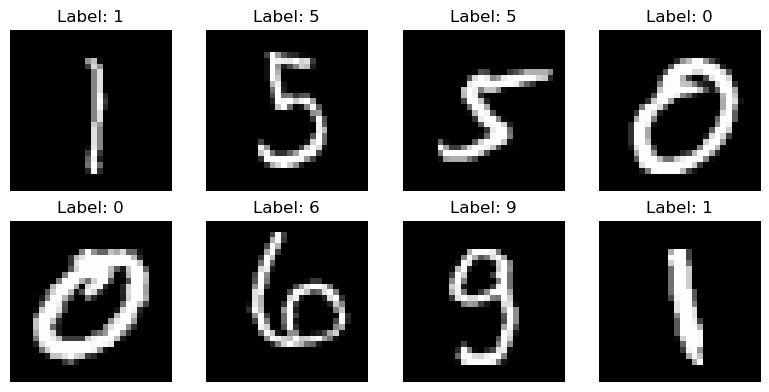

In [18]:
plt.figure(figsize=(8, 4))

for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(images[i].squeeze(), cmap="gray")
    plt.title(f"Label: {labels[i].item()}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [19]:

import torch.nn as nn
import torch.optim as optim

class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()

        self.conv_layers = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
        )

        self.fc_layers = nn.Sequential(
            nn.Linear(3 * 3 * 128, 256),
            nn.ReLU(),
            nn.Linear(256, 10),
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = x.view(x.size(0), -1)
        x = self.fc_layers(x)

        return x

In [20]:
model = CNN()

criterion =  nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters())

In [27]:
epochs = 10

for epoch in range(epochs):
    epoch_training_loss = 0.0

    for images, labels in train_loader:

        optimizer.zero_grad()

        output = model(images)
        loss = criterion(output, labels)

        loss.backward()
        optimizer.step()

        epoch_training_loss += loss.item()

    print(
        f"Epoch {epoch + 1}/{epochs}, "
        f"Loss: {epoch_training_loss / len(train_loader):.4f}"
    )

Epoch 1/10, Loss: 0.0438
Epoch 2/10, Loss: 0.0310
Epoch 3/10, Loss: 0.0234
Epoch 4/10, Loss: 0.0177
Epoch 5/10, Loss: 0.0161
Epoch 6/10, Loss: 0.0138
Epoch 7/10, Loss: 0.0109
Epoch 8/10, Loss: 0.0089
Epoch 9/10, Loss: 0.0089
Epoch 10/10, Loss: 0.0073


In [29]:
correct_labels = 0
total_labels = 0

model.eval()

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model.forward(images)
        _, predicted = torch.max(outputs, 1)

        correct_labels += (predicted == labels).sum().item()
        total_labels += labels.size(0)

print(f"accuracy = {correct_labels/total_labels * 100}")

accuracy = 98.82


In [31]:
model.eval()

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model.forward(images)
        _, predicted = torch.max(outputs, 1)

        correct_labels += (predicted == labels).sum().item()
        total_labels += labels.size(0)

print("accuracy: ", correct_labels/total_labels * 100)

accuracy:  98.82


In [35]:
class RNN(nn.Module):
    def __init__(self):
        super(RNN, self).__init__()

        self.rnn = nn.RNN(
            input_size=28,
            hidden_size=128,
            num_layers=1,
            batch_first=True
        )

        self.fc = nn.Linear(128, 10)

    def forward(self, x):
        output, hidden = self.rnn(x)

        x = hidden[-1]

        x = self.fc(x)

        return x

In [36]:
images, labels = next(iter(train_loader))

print(images.shape)

torch.Size([32, 1, 28, 28])


In [37]:
images = images.squeeze(1)

print(images.shape)

torch.Size([32, 28, 28])


In [39]:
model = RNN(
    input_size=28,
    hidden_size=128,
    num_layers=1
)

images, labels = next(iter(train_loader))
images = images.squeeze(1)

output = model(images)

print(images.shape)
print(output.shape)

torch.Size([32, 28, 28])
torch.Size([32, 10])


In [40]:
epochs = 10

for epoch in range(epochs):
    model.train()

    for Xb, yb in train_loader:

        optimizer.zero_grad()

        Xb = Xb.squeeze(1)

        outputs = model(Xb)

        loss = criterion(outputs, yb)

        loss.backward()

        optimizer.step()

    print(f"Epoch = {epoch+1}/{epochs}, Loss = {loss.item():.4f}")

Epoch = 1/10, Loss = 2.3066
Epoch = 2/10, Loss = 2.3018
Epoch = 3/10, Loss = 2.3133
Epoch = 4/10, Loss = 2.3091
Epoch = 5/10, Loss = 2.3123
Epoch = 6/10, Loss = 2.3152
Epoch = 7/10, Loss = 2.3258
Epoch = 8/10, Loss = 2.2908
Epoch = 9/10, Loss = 2.3251
Epoch = 10/10, Loss = 2.3103


In [41]:
model.eval()

with torch.no_grad():
    correct_vals = 0
    tot_vals = 0

    for Xb, yb in test_loader:

        Xb = Xb.squeeze(1)

        outputs = model(Xb)

        predicted = outputs.argmax(dim=1)

        tot_vals += yb.size(0)
        correct_vals += (predicted == yb).sum().item()

    print(f"accuracy = {correct_vals / tot_vals * 100:.2f}%")

accuracy = 10.28%
